# **E-Commerce Sales Analysis**

## **Objective**
upon initial inspection of the data, Now we are think of some question that we have to answer it.

* what are the overall sales trend?
* what are the top 10 sales product sales?
* what is the most selling product?
* what is the most preferred ship mode?
* what are the most preferred category and sub category?


**Importing** **important** **libraries**

In [5]:
# for data manipulation
import pandas as pd

# for data visualization
import matplotlib.pyplot as plt
%matplotlib inline

# for data visualization
import seaborn as sns


In [6]:
df = pd.read_csv('/content/samplesuperstore.csv')


**Data Audit**

In [7]:
# first five rows of loaded dataset
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [8]:
# last five rows of loaded dataset
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
10189,10190,US-2026-143259,12/30/2026,1/3/2027,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
10190,10191,US-2026-115427,12/30/2026,1/3/2027,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750
10191,10192,US-2026-156720,12/30/2026,1/3/2027,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048
10192,10193,US-2026-143259,12/30/2026,1/3/2027,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
10193,10194,CA-2026-143500,12/30/2026,1/3/2027,Standard Class,HO-15230,Harry Olson,Consumer,Canada,Charlottetown,...,C0A,East,OFF-BI-10004040,Office Supplies,Binders,Wilson Jones Impact Binders,3.024,3,0.2,-0.6048


In [9]:
# Shape of loaded dataset
df.shape

(10194, 21)

In [10]:
# Columns presenting in loaded dataset
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [11]:
# loaded data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  object 
 6   Customer Name   10194 non-null  object 
 7   Segment         10194 non-null  object 
 8   Country/Region  10194 non-null  object 
 9   City            10194 non-null  object 
 10  State/Province  10194 non-null  object 
 11  Postal Code     10194 non-null  object 
 12  Region          10194 non-null  object 
 13  Product ID      10194 non-null  object 
 14  Category        10194 non-null  object 
 15  Sub-Category    10194 non-null  object 
 16  Product Name    10194 non-null  object 
 17  Sales           10194 non-null 

In [12]:
# for checking missing value from data
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country/Region,0
City,0


In [13]:
# Getting describtion statistics summary
df.describe() # this will give the information of only those Column which have int or floating data type

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


## **Exploratory data analysis**

* what is the overall sales trend?


In [14]:
df['Order Date'].min()

'1/1/2026'

In [15]:
df['Order Date'].max()

'9/9/2026'

In [16]:
# getting data and time from tha loaded data set
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['month_year'] = df['Order Date'].apply(lambda x: x.strftime('%Y-%m'))
df['month_year']

,month_year
0,2023-01
1,2023-01
2,2023-01
3,2023-01
4,2023-01
...,...
10189,2026-12
10190,2026-12
10191,2026-12
10192,2026-12


In [32]:
# Grouping the month and year
df_trend =  df.groupby('month_year')['Sales'].sum().reset_index() # calculate total sales for each month and year
df_trend

,month_year,Sales
0,2023-01,14518.0550
1,2023-02,4519.8920
2,2023-03,56933.9090
3,2023-04,28295.3450
4,2023-05,26319.7670
5,2023-06,34669.4796
6,2023-07,33946.3930
7,2023-08,28918.3385
8,2023-09,82670.4288
9,2023-10,32413.3390


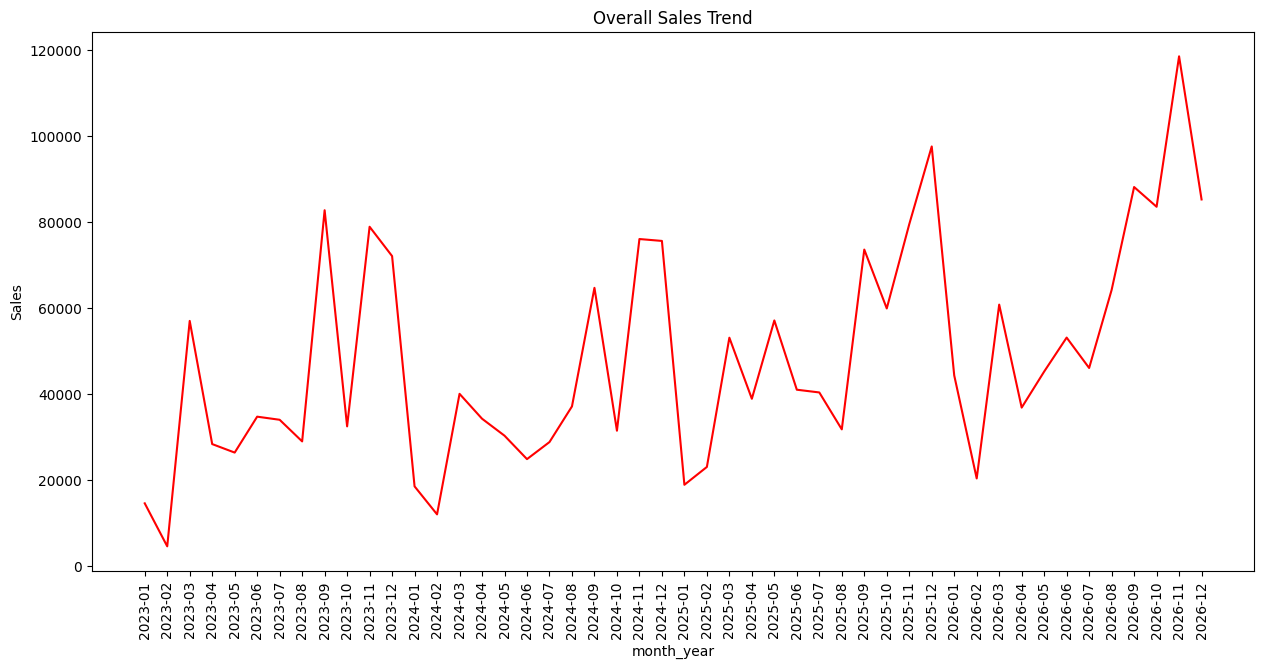

In [40]:
# custmizing the size of figure
plt.figure(figsize=(15, 7))
plt.plot(df_trend['month_year'], df_trend['Sales'],color='red')
plt.xlabel('month_year')
plt.ylabel('Sales')
plt.title('Overall Sales Trend')
plt.xticks(rotation=90)
plt.show()

## **what are the top 10 product of sales?**

In [41]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,month_year
0,1,US-2023-103800,2023-01-03,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023-01
1,2,US-2023-112326,2023-01-04,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023-01
2,3,US-2023-112326,2023-01-04,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717,2023-01
3,4,US-2023-112326,2023-01-04,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023-01
4,5,US-2023-141817,2023-01-05,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023-01


In [93]:
df[['Product Name','Sales']]

# now group the product Name amd sales
df_product_sales = df.groupby('Product Name')['Sales'].sum().reset_index()
df_product_sales.head()

,Product Name,Sales
0,"""While you Were Out"" Message Book, One Form pe...",25.228
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300
2,#10 Self-Seal White Envelopes,108.682
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",488.904
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672


In [60]:
from itertools import product
df_product_sales.sort_values(by='Sales', ascending=False, inplace=True)
product_sales = df_product_sales.head(10)
product_sales

,Product Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
785,HON 5400 Series Task Chairs for Big and Tall,21870.576
685,GBC DocuBind TL300 Electric Binding System,19823.479
687,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
804,Hewlett Packard LaserJet 3310 Copier,18839.686
786,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
682,GBC DocuBind P400 Electric Binding System,17965.068
812,High Speed Automatic Electric Letter Opener,17030.312


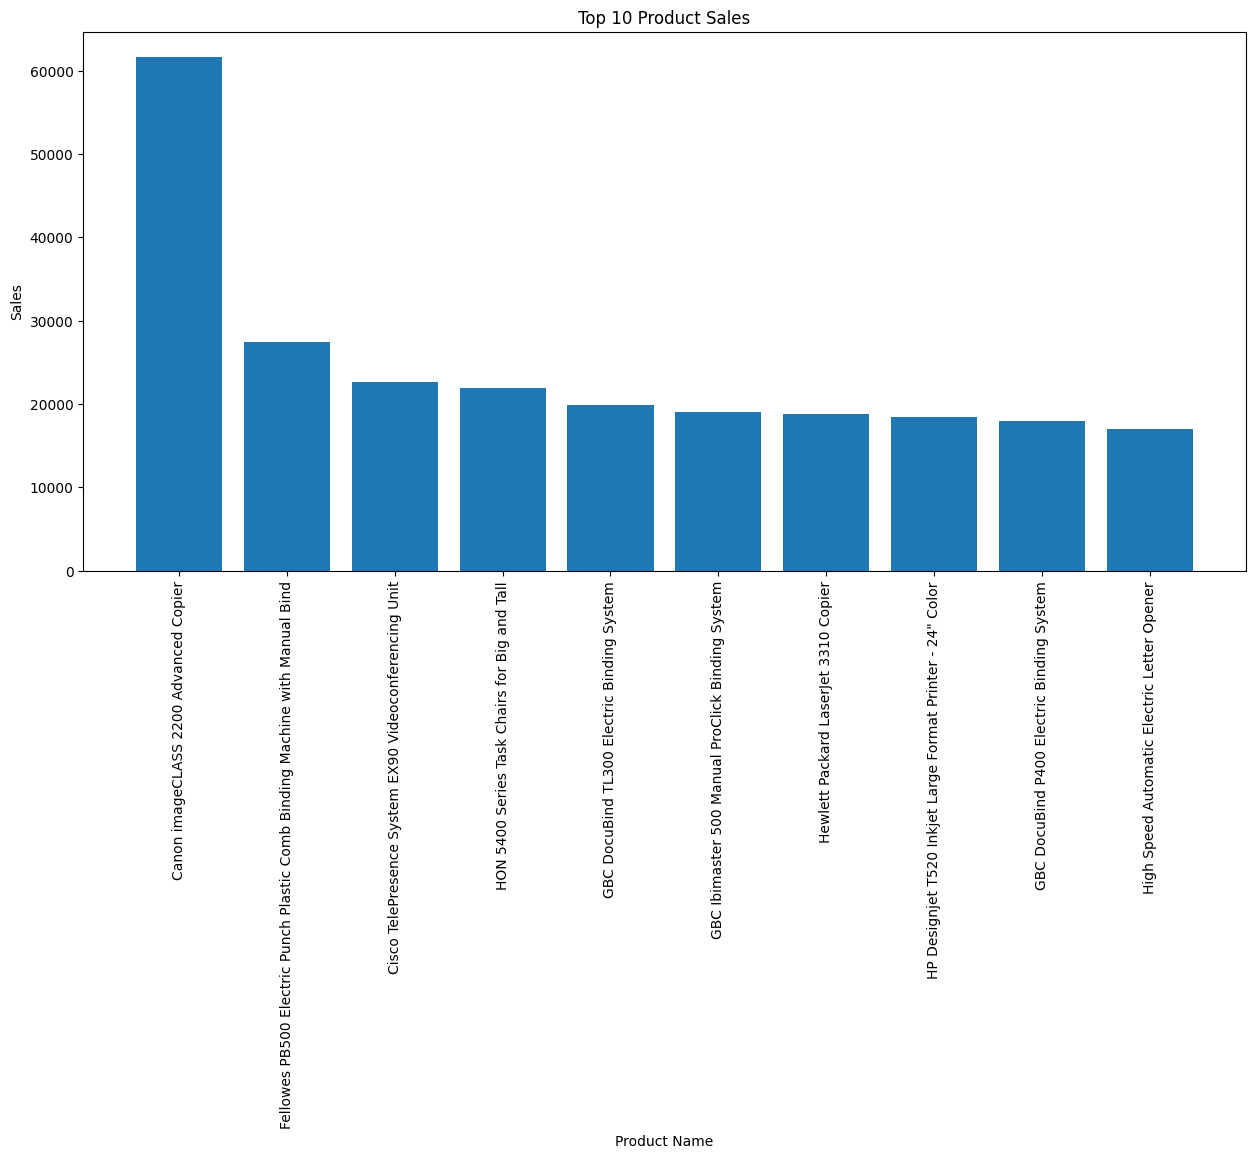

In [62]:
# increasing the figure size
plt.figure(figsize=(15, 7))
plt.bar(product_sales['Product Name'], product_sales['Sales'])
plt.xlabel('Product Name')
plt.ylabel('Sales')
plt.title('Top 10 Product Sales')
plt.xticks(rotation=90)
plt.show()

In [63]:
# So the top 10 product of sales are:
product_sales[:10]

,Product Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
785,HON 5400 Series Task Chairs for Big and Tall,21870.576
685,GBC DocuBind TL300 Electric Binding System,19823.479
687,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
804,Hewlett Packard LaserJet 3310 Copier,18839.686
786,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
682,GBC DocuBind P400 Electric Binding System,17965.068
812,High Speed Automatic Electric Letter Opener,17030.312


**What are the most selling products?**

In [78]:
# grouping the product and quantity
most_selling_product = df.groupby('Product Name')['Quantity'].sum()
most_selling_product

,Quantity
Product Name,
"""While you Were Out"" Message Book, One Form per Page",8
"#10 Gummed Flap White Envelopes, 100/Box",11
#10 Self-Seal White Envelopes,10
"#10 White Business Envelopes,4 1/8 x 9 1/2",32
"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",37
...,...
"iKross Bluetooth Portable Keyboard + Cell Phone Stand Holder + Brush for Apple iPhone 5S 5C 5, 4S 4",64
iOttie HLCRIO102 Car Mount,12
iOttie XL Car Mount,14


In [83]:
# sorting most selling product
most_selling_product.sort_values(ascending=False)

,Quantity
Product Name,
Staples,234
Staple envelope,170
Easy-staple paper,150
Staples in misc. colors,86
Nu-Dell Executive Frame,84
...,...
Boston 1900 Electric Pencil Sharpener,1
Global Enterprise Series Seating Low-Back Swivel/Tilt Chairs,1
"Bush Saratoga Collection 5-Shelf Bookcase, Hanover Cherry, *Special Order",1


In [86]:
most_selling_product[:10]
# is same as :
# most_selling_product.head(10)

,Quantity
Product Name,
Staples,234
Staple envelope,170
Easy-staple paper,150
Staples in misc. colors,86
Nu-Dell Executive Frame,84
KI Adjustable-Height Table,79
GBC DocuBind P50 Personal Binding Machine,72
Avery Non-Stick Binders,71
Storex Dura Pro Binders,71


## **What is the most preferred ship mode**

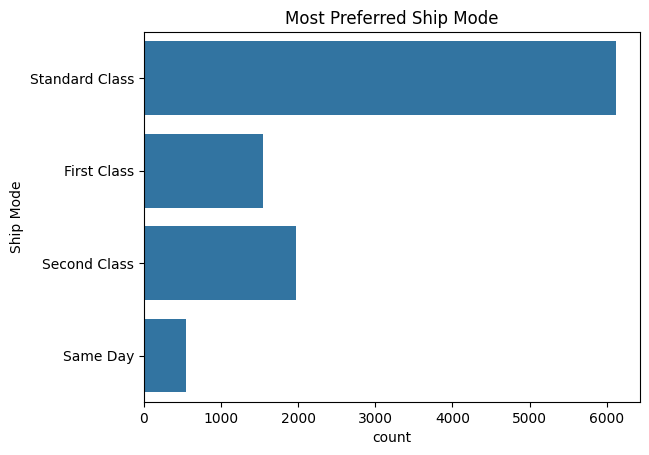

In [91]:
sns.countplot(df['Ship Mode'])
plt.title('Most Preferred Ship Mode')
plt.show()


## **What is the most profitable category and sub category**

In [112]:
cat_subcat_profit =(df.groupby(['Category','Sub-Category'])['Profit'].sum().reset_index())
cat_subcat_profit

,Category,Sub-Category,Profit
0,Furniture,Bookcases,-3632.0736
1,Furniture,Chairs,27223.5323
2,Furniture,Furnishings,13891.7430
3,Furniture,Tables,-17753.2061
4,Office Supplies,Appliances,18329.4844
5,Office Supplies,Art,6653.1962
6,Office Supplies,Binders,31426.1003
7,Office Supplies,Envelopes,6988.0247
8,Office Supplies,Fasteners,2428.6358
9,Office Supplies,Labels,5572.7780


In [116]:
plot_cat_subcat_profit = cat_subcat_profit.sort_values(by='Profit', ascending=False)
plot_cat_subcat_profit

,Category,Sub-Category,Profit
14,Technology,Copiers,56093.9365
16,Technology,Phones,45050.8265
13,Technology,Accessories,41936.6357
10,Office Supplies,Paper,34511.5070
6,Office Supplies,Binders,31426.1003
1,Furniture,Chairs,27223.5323
11,Office Supplies,Storage,21285.1115
4,Office Supplies,Appliances,18329.4844
2,Furniture,Furnishings,13891.7430
7,Office Supplies,Envelopes,6988.0247
